# Quick Start

This notebook shows the minimal workflow: fit Poincaré Maps embeddings on a graph and visualize the result in the Poincaré disk.

In [ ]:
# comment if unnecessary
!pip install git+https://github.com/git-artes/hypeGRL

import networkx as nx
import matplotlib
from hypegrl.embedders.poincare_maps import PoincareMapsEmbedder
from hypegrl.visualization.disk import plot_poincare_graph

## Load a graph

We use the Zachary karate club graph as a running example.

In [7]:
G = nx.karate_club_graph()
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

Nodes: 34, Edges: 78


## Fit embeddings

In [8]:
embedder = PoincareMapsEmbedder(
    d=2,
    gamma=1.0,
    n_steps=300,
    lr_X=1e-2,
    log_every=50,
    random_state=0,
)
embedder.fit(G)
X = embedder.embeddings()
print(f'Embeddings shape: {X.shape}')

Step    0 | Loss: 12.781372 | a_Omega: []
Step   50 | Loss: 9.178355 | a_Omega: []
Step  100 | Loss: 7.934666 | a_Omega: []
Step  150 | Loss: 7.513316 | a_Omega: []
Step  200 | Loss: 6.398354 | a_Omega: []
Step  250 | Loss: 6.118649 | a_Omega: []
Step  299 | Loss: 5.878857 | a_Omega: []
Embeddings shape: (34, 2)


## Visualise in the Poincaré disk

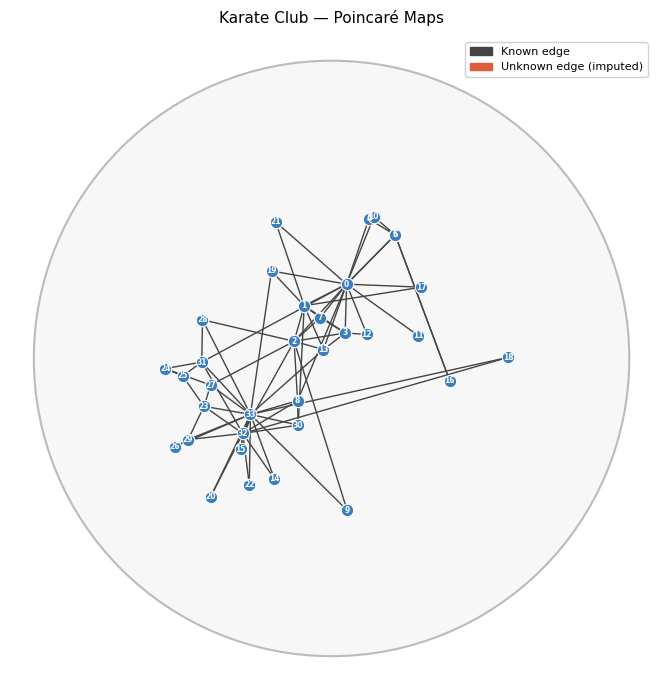

In [10]:
fig = plot_poincare_graph(
    G, X,
    title='Karate Club — Poincaré Maps',
)
fig.show()

## Loss curve

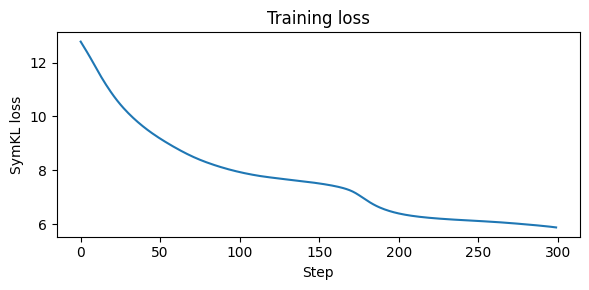

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(embedder.loss_history)
plt.xlabel('Step'); plt.ylabel('SymKL loss')
plt.title('Training loss'); plt.tight_layout()
plt.show()